In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns
from utils import train_test_split, shuffle_data, mse, ridge_mse, make_folds, standardise

sns.set_style("whitegrid")

In [117]:
df = pd.read_csv("../Data/c_w_data.csv")

## 1. Data Setup

Our dataset contains various categorical columns, which we need to one-hot encode. Furthermore, we have multiple different target columns, only one of which ("dj_odds") lends itself to numerical regression models, and including the others ("Score" and "dj_win") would result in data leakage. Let us set up the data accordingly.

In [118]:
df.head()

,Series,Surface,Round,Score,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets,5SMA
0,International,Clay,2nd Round,6-4 6-2,417,97,5.00,1170,28,1.14,0,18,1,0,1.000000
1,Masters,Hard,1st Round,6-3 6-7 4-6,440,97,3.50,1385,18,1.28,0,18,1,0,0.500000
2,Grand Slam,Hard,1st Round,7-5 4-6 7-5 0-6 7-5,431,97,2.50,825,43,1.50,1,18,1,1,0.333333
3,Grand Slam,Hard,2nd Round,6-3 5-7 7-6 6-3,431,97,3.50,1230,24,1.28,1,18,1,1,0.500000
4,Grand Slam,Hard,3rd Round,1-6 6-4 7-6 4-6 4-6,431,97,2.75,770,48,1.39,0,18,1,1,0.600000


Firstly, we must use one-hot encoding to create categorical variables to use for our regression. Once we have the one hot encoded dataframe, we can drop the corresponding columns in the original dataframe, and then concatenate the one-hot dataframe with the original.

In [119]:
encoded = pd.concat([pd.get_dummies(df["Series"]).astype(int),
                    pd.get_dummies(df["Surface"]).astype(int),
                    pd.get_dummies(df["Round"]).astype(int)], axis=1)

In [120]:
encoded.head()

,ATP250,ATP500,Grand Slam,International,International Gold,Masters,Masters 1000,Masters Cup,Carpet,Clay,Grass,Hard,1st Round,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0


In [121]:
df = df.copy().drop(columns=['Series', 'Surface', 'Round'])

We must drop the Score and dj_win columns since these are only available for each match once we know the outcome. Keeping these in the dataframe for the linear regression will result in unwanted data leakage.

In [122]:
df = df.copy().drop(columns=['Score', 'dj_win'])

Now we form the prediction variable matrix and the target variable vector.

In [123]:
y = df['dj_odds'].to_numpy()
X = df[['dj_pts', 'dj_rank', 'opp_pts', 'opp_rank', 'opp_odds',
       'age', 'is_outdoor', 'is_five_sets', '5SMA']].to_numpy()

Now, we shuffle our data so that our model doesn't learn / memorise a specific time frame of the data. Then perform a train / test split and standardise the data to ensure stability when training. Standardisation is done to prevent information leakage from the training set into the test set. Finally, we augment our datasets to learn an intercept term by adding a column of ones. 

Note: since we have a 5-day moving average column, there is not complete independence between the train and test datasets, since after shuffling, we will have entries in this column that have been computed using rows in the training set.

Note: if we were trying to learn the performance of a player in current matches, we would want to train on matches earlier in the career, and then test on later matches to evaluate how good the model performs on the matches we actually care about.

In [124]:
shuff_X, shuff_y = shuffle_data(X, y)
X_train, X_test, y_train, y_test = train_test_split(shuff_X, shuff_y, 0.8)
X_train_std = standardise(X_train)
X_test_std = standardise(X_test, scaler=X_train)
X_train_aug = np.hstack([np.ones((X_train.shape[0], 1)), X_train_std])
X_test_aug = np.hstack([np.ones((X_test.shape[0], 1)), X_test_std])

## 2. Least Squares Regression

In [125]:
# Computing coefficients vector
theta = np.linalg.solve(X_train_aug.T @ X_train_aug, X_train_aug.T @ y_train)

In [126]:
# Calculating mean squared error on train set
y_train_hat = X_train_aug @ theta
mse_train = mse(y_train, y_train_hat)

In [127]:
# Calculating mean squared error on test set
y_test_hat = X_test_aug @ theta
mse_test = mse(y_test, y_test_hat)

In [128]:
print("Mean squared errors on train and test set for classic least squares")
print("-"*70)
print(f"Train set: {mse_train}")
print(f"Test set: {mse_test}")

Mean squared errors on train and test set for classic least squares
----------------------------------------------------------------------
Train set: 0.28600423623050825
Test set: 0.5863184646254915


## 3. Ridge Regression

Now we will use a ridge regression model. This may improve our mean squared error as ridge introduces a little bias but decreases the variance of the estimators, and of course $mse = bias^2 + variance$. We will use a hyperparameter search to establish the optimal value for $\lambda$. There is almost certainly some colinearity between the features, (such as dj_pts and dj_rank), hence ridge regression should give us a better mean squared error.

In [132]:
# Set hyperparameter search grid
resolution = 1000
lambdas = np.logspace(-4, 4, num=resolution)
thetas = np.zeros(resolution)
avg_val_mses = np.zeros(resolution)
penal_id = np.eye(X_train_aug.shape[1])
penal_id[0, 0] = 0

# Getting fold indices
k = 5
folds = make_folds(X_train, k)

# Hyperparameter search
for i, lam in enumerate(lambdas):
    val_mses = []
    for j in range(k):

        # Making the folds for this cross-validation iteration
        val_fold = folds[j]
        train_folds = np.hstack(folds[:j] + folds[j+1:])

        X_train_fold = X_train[train_folds]
        X_val_fold = X_train[val_fold]

        y_train_fold = y_train[train_folds]
        y_val_fold = y_train[val_fold]

        # Standardising the predictors
        X_train_std = standardise(X_train_fold)
        X_val_std = standardise(X_val_fold, scaler=X_train_fold)

        # Augmenting matrices to add intercept term
        X_train_aug_fold = np.hstack([np.ones((X_train_std.shape[0], 1)), X_train_std])
        X_val_aug_fold = np.hstack([np.ones((X_val_std.shape[0], 1)), X_val_std])

        # Get coefficients
        theta_lam = np.linalg.solve(X_train_aug_fold.T @ X_train_aug_fold + lam * penal_id,
                                    X_train_aug_fold.T @ y_train_fold)

        # val mse
        y_hat_fold = X_val_aug_fold @ theta_lam
        mse_val_r = mse(y_val_fold, y_hat_fold)

        val_mses.append(mse_val_r)

    avg_mse = np.mean(val_mses)
    avg_val_mses[i] = avg_mse

# Find optimal lam
opt_i = np.argmin(avg_val_mses)
opt_lam = lambdas[opt_i]

print(f"The optimal lambda is: {opt_lam}")


The optimal lambda is: 13.095350204826676


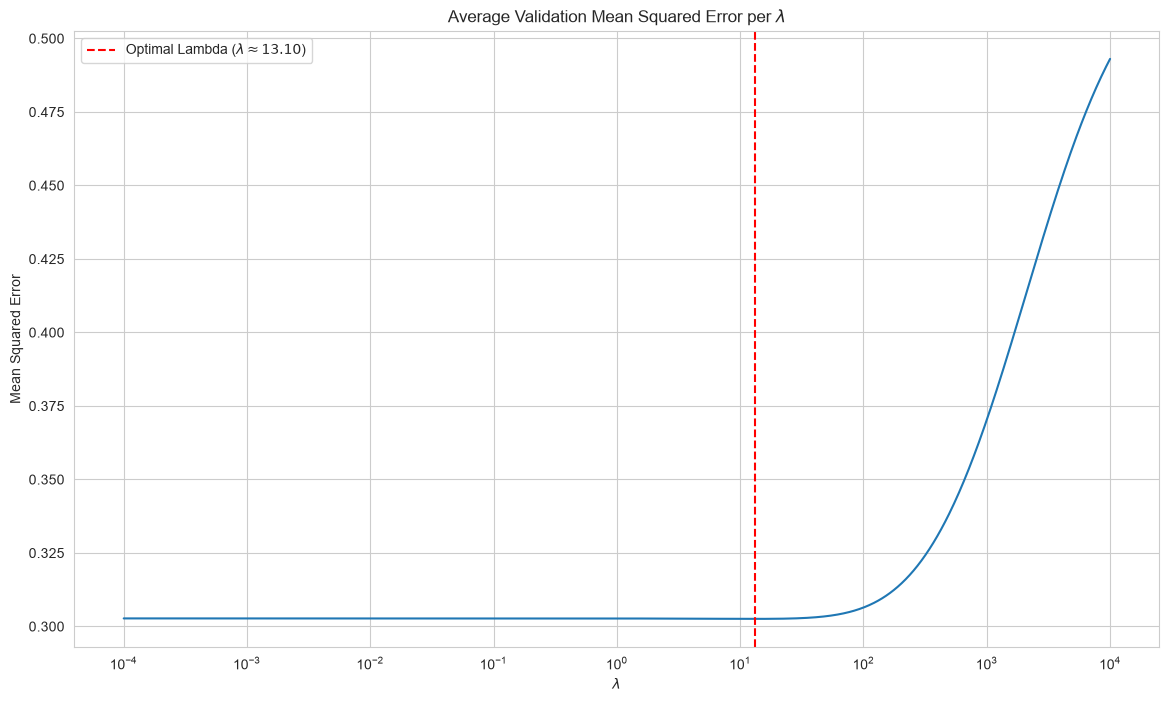

In [134]:
plt.figure(figsize=(14, 8))
plt.plot(lambdas, avg_val_mses)
plt.xscale("log")
plt.axvline(opt_lam, color="red", linestyle="--",
            label=rf"Optimal Lambda ($\lambda \approx {opt_lam:.2f}$)")
plt.title(r"Average Validation Mean Squared Error per $\lambda$")
plt.ylabel("Mean Squared Error")
plt.xlabel(r"$\lambda$")
plt.legend()
plt.show()


Note that this is the optimal $\lambda$ over the grid we have searched. The true optimal $\lambda$ may take a different value, in fact it almost certainly does since it can be anything on the number line and we have only searched a coarsely discrete space. Anyway, let us now work out the mean squared using this $\lambda$, which requires to first retrain the ridge model on the entire train set, and then we can evaluate on the test set just as we did with the least squares model.

In [135]:
# Get coefficients with optimal lambda
ridge_theta = np.linalg.solve(X_train_aug.T @ X_train_aug + opt_lam * penal_id,
                                X_train_aug.T @ y_train)

# Getting test and train predictions
y_hat_ridge_train = X_train_aug @ ridge_theta
y_hat_ridge_test = X_test_aug @ ridge_theta

# Calculate mses
train_mse_ridge = mse(y_hat_ridge_train, y_train)
test_mse_ridge = mse(y_hat_ridge_test, y_test)

print("Mean squared errors on train and test set for ridge regression")
print("-"*70)
print(f"Train set: {train_mse_ridge}")
print(f"Test set: {test_mse_ridge}")

Mean squared errors on train and test set for ridge regression
----------------------------------------------------------------------
Train set: 0.28611215831350645
Test set: 0.5876918494745133


## 4. LASSO Regression

We now implement a LASSO regression, which encourages shrinkage of certain coefficients to zero. It is informative to see which coefficients shrink the most / fastest. These are the ones the model deems least useful in the prediction and allows to shrink first as the corresponding features do not contribute much to reducing the mean squared error.

The LASSO uses an $L_1$ regularisation. Since the $L_1$ norm doesn't lend itself to a closed form like the $L_2$ norm does, I will use a Huber smoothing approximation and then perform a gradient descent.

In [ ]:
def huber(theta, mu=1e-4):

    """
        Calculates the huber L_1 approximation.
    """

    abs_theta = np.abs(theta)
    return np.where(abs_theta < mu, abs_theta**2 / (2 * mu), abs_theta - mu / 2)


In [ ]:
def huber_grad(theta, mu = 1e-4):

    """
        Calculates the gradient of the huber L_1 approximation.
    """

    abs_theta = np.abs(theta)

    return np.where(abs_theta < mu, abs_theta / mu, np.sign(theta))